

### Architecture
In this experiment, EfficientNet_B1 is applied and last layer is removed with single output for the pawpularity finetuning without metadata inclusion. strong augmentation is added.



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config


main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp2_384_effB1_batchSize12_mlpHead_MSELoss_Seed50")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp2"]
cfg["img_size"] = 384
cfg["aug"] = "strong"
cfg["backbone"] = "efficientnet_b1"
cfg["name"] = "exp2_384_effB1_batchSize12_mlpHead_MSELoss_Seed50"
cfg["batch_size"] = 12
cfg["head_type"] = "mlp"
cfg["loss"] = "mse"
cfg["seed"] = 50
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp2_384_effB1_batchSize12_mlpHead_MSELoss_Seed50: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=32.0428 | ValRMSE: 19.2838
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=19.1593 | ValRMSE: 18.4981
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=18.4329 | ValRMSE: 18.7316
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=17.8298 | ValRMSE: 19.7109
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=17.3025 | ValRMSE: 18.9032
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=16.3370 | ValRMSE: 18.9965
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=15.6632 | ValRMSE: 19.7067
Early stopping at epoch 7
Fold 1 best RMSE: 18.4981

=== exp2_384_effB1_batchSize12_mlpHead_MSELoss_Seed50: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=32.3269 | ValRMSE: 20.1942
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=19.0206 | ValRMSE: 19.2520
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=18.2108 | ValRMSE: 18.9748
Epoch 4/10 | Fold 2 | Train[MSE]: RMSE=17.6409 | ValRMSE: 19.2271
Epoch 5/10 | Fold 2 | Train[MSE]: RMSE=16.8975 | ValRMSE: 19.4458
Epoch 6/10 | Fold 2 | 

In [5]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.4981 (n=1983)
Fold 2 OOF RMSE: 18.9748 (n=1983)
Fold 3 OOF RMSE: 19.5764 (n=1982)
Fold 4 OOF RMSE: 18.4211 (n=1982)
Fold 5 OOF RMSE: 18.8002 (n=1982)


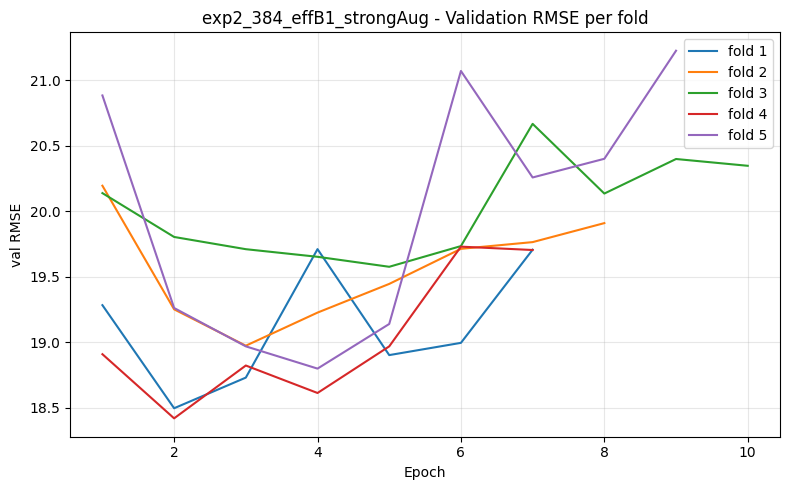

In [6]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp2_384_effB1_strongAug")


In [7]:
# Worst error images 
errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


,Id,fold,ytrue,oof_pred,abs_err
0,d00e5d29d4ec09de1e0e0ebec41b2d03,3,5,123.932861,118.932861
1,9fdfa0708e98d8320e0b526315bb264a,3,7,108.085777,101.085777
2,215d552ffa96127d0cee430d3d8c96de,5,36,121.625710,85.625710
3,4c1e05895368c997fdd709bbd1ac3dae,4,2,87.258965,85.258965
4,76769dbee1699e04ae1befa3128db7d6,5,100,18.592703,81.407297


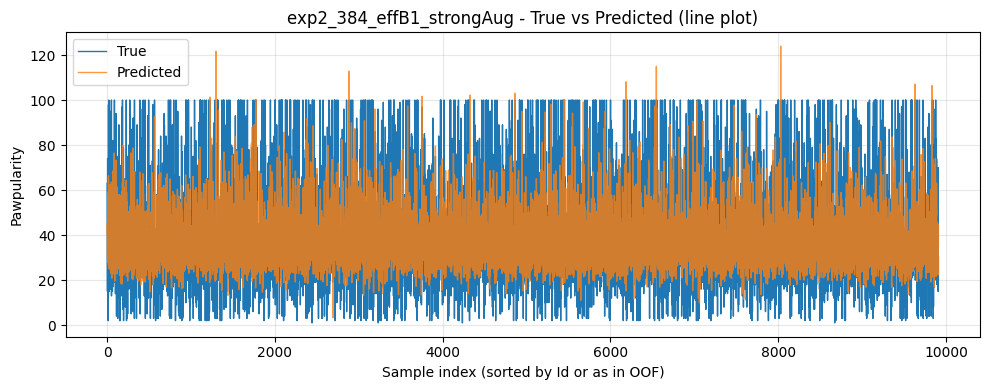

In [8]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp2_384_effB1_strongAug")





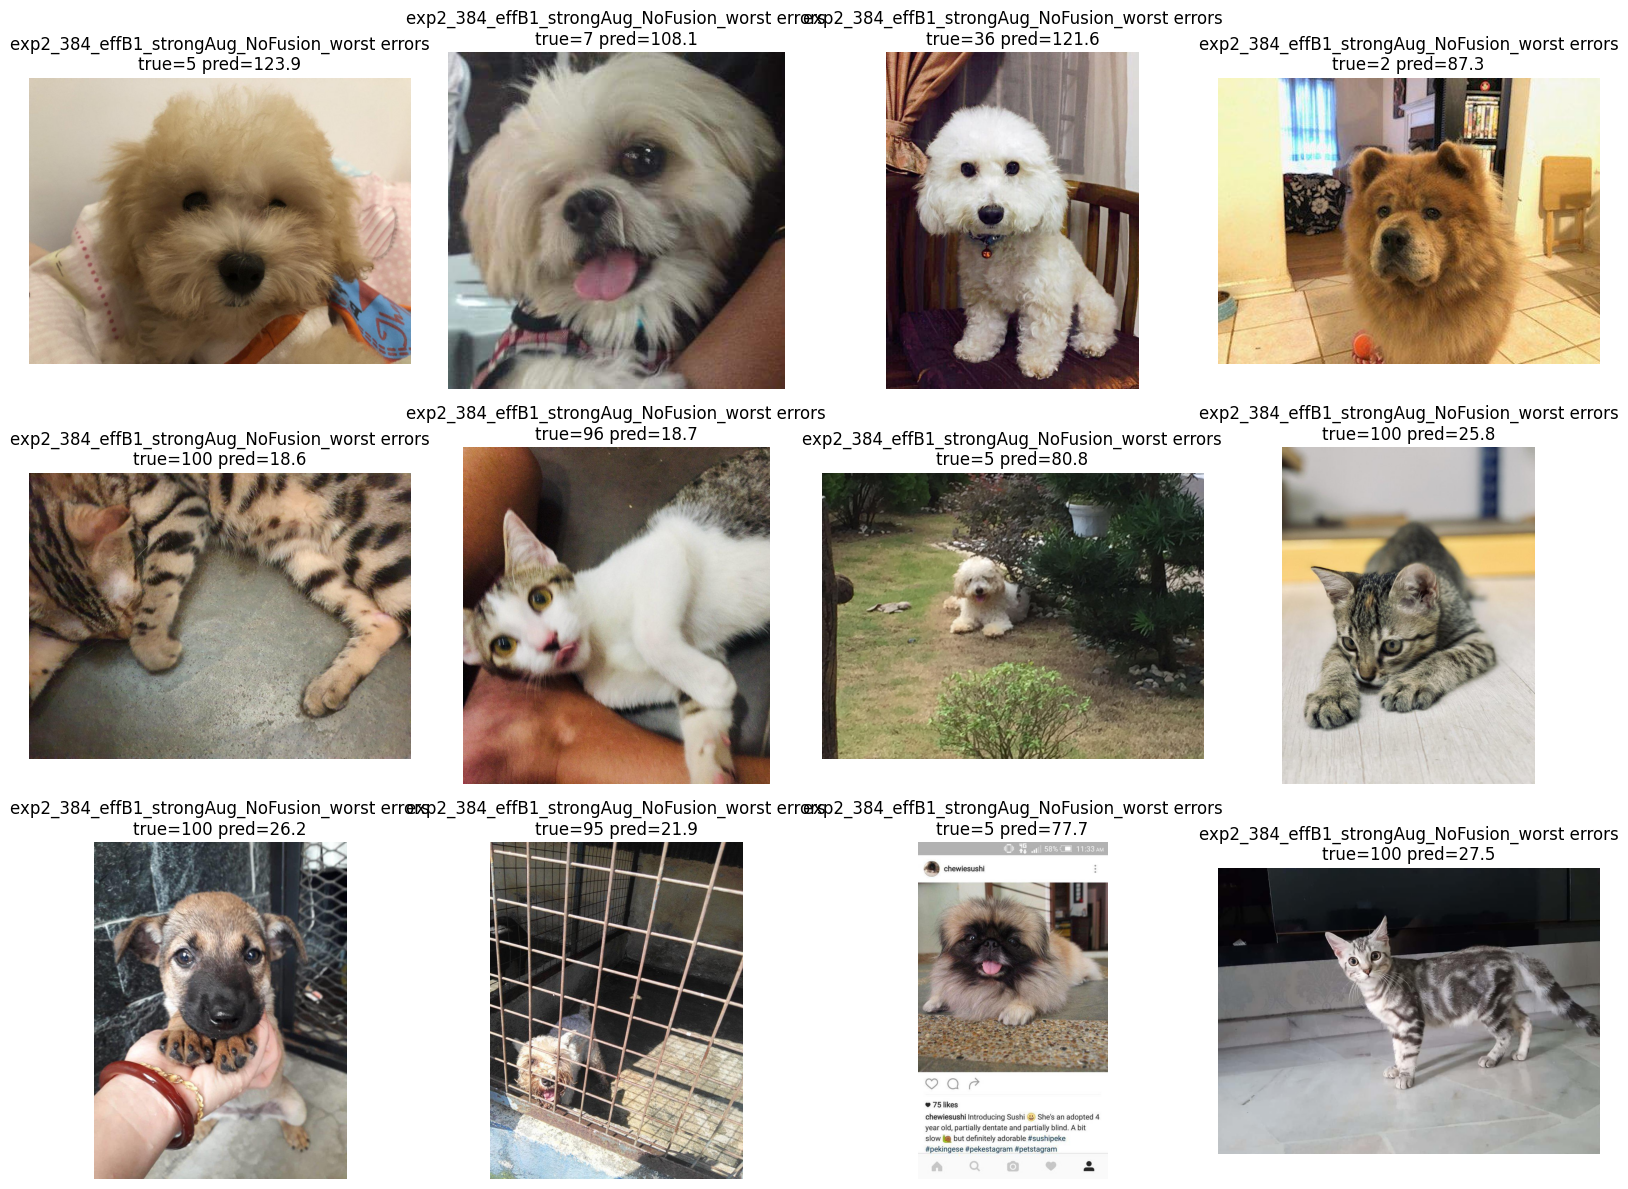

In [9]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp2_384_effB1_strongAug_NoFusion_worst errors")

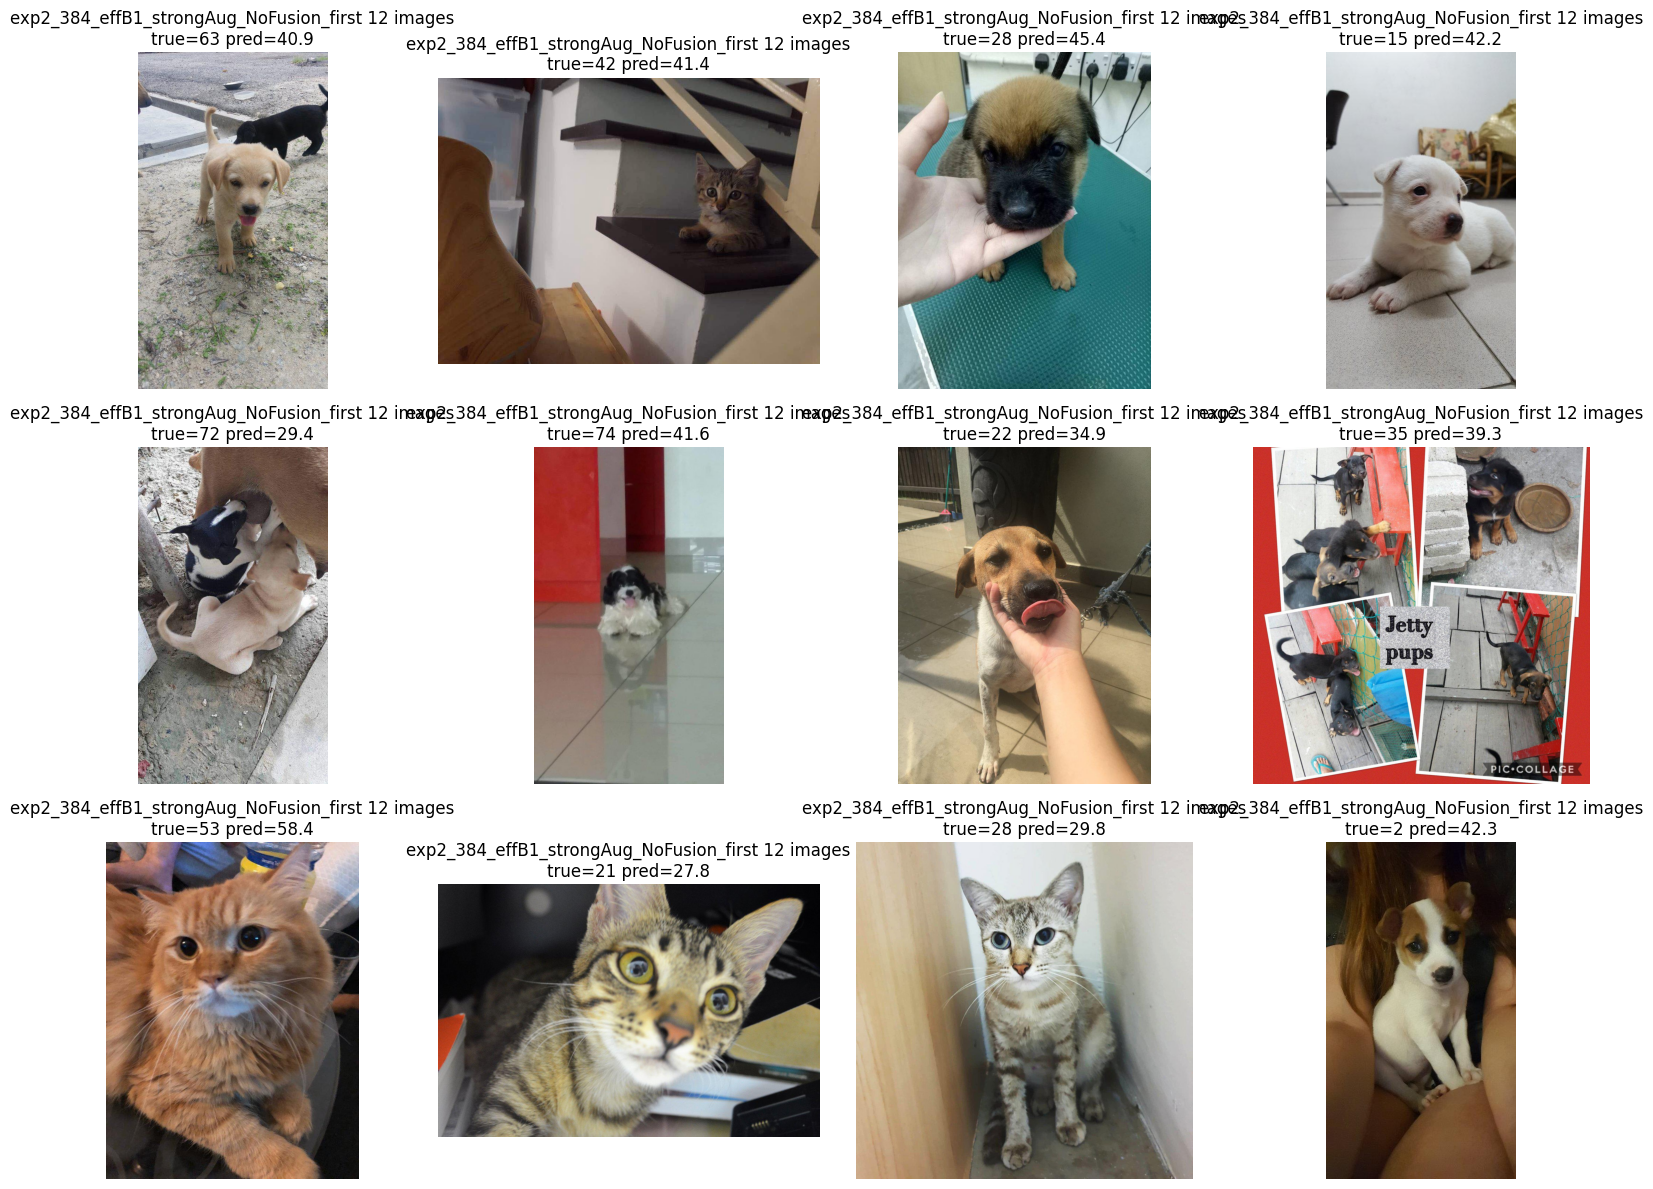

In [10]:

show_images_grid(oof_df, img_folder, n=12, title_prefix="exp2_384_effB1_strongAug_NoFusion_first 12 images")